## 0. Install & Import

In [ ]:
!pip install -q lightgbm xgboost imbalanced-learn

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from scipy import stats, signal
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Mount Google Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # ======================================================
# # ✏️ แก้ path ตรงนี้ให้ตรงกับที่เก็บไฟล์ใน Drive
# # ======================================================
# TRAIN_DIR = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/train'
# TEST_DIR  = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment'
# SAMPLE_SUBMISSION = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/sample_submission.csv'

# # Hyperparams
# FS = 16          # sampling rate (Hz)
# SEG_SEC = 30     # seconds per segment
# SEG_LEN = FS * SEG_SEC  # 480 samples per segment

# COLS = ['BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'TEMP', 'EDA', 'HR', 'IBI']
# LABEL_COL = 'Sleep_Stage'
# CLASSES = ['W', 'N1', 'N2', 'N3', 'R']

# print(f'Segment length: {SEG_LEN} samples = {SEG_SEC}s @ {FS}Hz')


# === แก้ Path ก่อน ===
BASE_DIR   = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train_segment')   # ✏️ แก้ชื่อให้ตรงกับ train folder จริง
TEST_DIR   = os.path.join(BASE_DIR, 'test_segment', 'test_segment')  # ซ้อน 2 ชั้น
SAMPLE_SUB = os.path.join(BASE_DIR, 'sample_submission.csv')

# ตรวจ path
print("Test subjects:", sorted(os.listdir(TEST_DIR)))
print("Sample sub exists:", os.path.exists(SAMPLE_SUB))

Test subjects: ['test001', 'test002', 'test003', 'test004', 'test005', 'test006', 'test007', 'test008', 'test009', 'test010']
Sample sub exists: True


In [ ]:
import os, glob

BASE_DIR  = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569'

print("=== Contents of BASE_DIR (top level) ===")
for item in sorted(os.listdir(BASE_DIR)):
    full = os.path.join(BASE_DIR, item)
    if os.path.isdir(full):
        files = os.listdir(full)
        print(f"  📁 {item}/  ({len(files)} items)")
    else:
        print(f"  📄 {item}")

=== Contents of BASE_DIR (top level) ===
  📄 sample_submission.csv
  📁 test_segment/  (1 items)
  📁 train/  (1 items)


## 2. Feature Extraction Functions

In [ ]:
def extract_time_features(arr, col_name):
    """Statistical time-domain features for one signal segment."""
    feats = {}
    feats[f'{col_name}_mean']    = np.mean(arr)
    feats[f'{col_name}_std']     = np.std(arr)
    feats[f'{col_name}_min']     = np.min(arr)
    feats[f'{col_name}_max']     = np.max(arr)
    feats[f'{col_name}_range']   = np.ptp(arr)
    feats[f'{col_name}_median']  = np.median(arr)
    feats[f'{col_name}_iqr']     = stats.iqr(arr)
    feats[f'{col_name}_skew']    = stats.skew(arr)
    feats[f'{col_name}_kurt']    = stats.kurtosis(arr)
    feats[f'{col_name}_rms']     = np.sqrt(np.mean(arr**2))
    feats[f'{col_name}_cv']      = np.std(arr) / (np.mean(arr) + 1e-8)  # coefficient of variation
    # Zero-crossing rate
    feats[f'{col_name}_zcr']     = np.sum(np.diff(np.sign(arr - np.mean(arr))) != 0)
    # Peak count (rough)
    peaks, _ = signal.find_peaks(arr)
    feats[f'{col_name}_npeaks']  = len(peaks)
    return feats


def extract_freq_features(arr, col_name, fs=FS):
    """Power spectral density features (Welch method)."""
    feats = {}
    nperseg = min(len(arr), 128)
    freqs, psd = welch(arr, fs=fs, nperseg=nperseg)

    # Band powers — adapt bands for each signal if needed
    bands = {
        'vlf': (0.0, 0.04),
        'lf':  (0.04, 0.15),
        'hf':  (0.15, 0.40),
        'vhf': (0.40, fs/2),
    }
    total_power = np.trapz(psd, freqs) + 1e-8
    for band, (lo, hi) in bands.items():
        idx = (freqs >= lo) & (freqs < hi)
        bp = np.trapz(psd[idx], freqs[idx]) if idx.any() else 0.0
        feats[f'{col_name}_pwr_{band}']     = bp
        feats[f'{col_name}_relpwr_{band}']  = bp / total_power

    feats[f'{col_name}_lf_hf_ratio'] = (
        feats[f'{col_name}_pwr_lf'] / (feats[f'{col_name}_pwr_hf'] + 1e-8)
    )
    feats[f'{col_name}_dom_freq'] = freqs[np.argmax(psd)]
    feats[f'{col_name}_total_pwr'] = total_power
    return feats


def extract_acc_mag(df):
    """Accelerometer magnitude (ACC_X^2 + ACC_Y^2 + ACC_Z^2)^0.5."""
    return np.sqrt(df['ACC_X']**2 + df['ACC_Y']**2 + df['ACC_Z']**2).values


def extract_segment_features(seg_df):
    """Extract all features for one 30-second segment DataFrame."""
    feats = {}

    for col in COLS:
        arr = seg_df[col].values.astype(float)
        feats.update(extract_time_features(arr, col))
        # Freq features only for signals with meaningful temporal variation
        if col in ['BVP', 'EDA', 'HR']:
            feats.update(extract_freq_features(arr, col))

    # Accelerometer magnitude
    acc_mag = extract_acc_mag(seg_df)
    feats.update(extract_time_features(acc_mag, 'ACC_mag'))
    feats.update(extract_freq_features(acc_mag, 'ACC_mag'))

    return feats


print('Feature functions defined ✅')

Feature functions defined ✅


## 3. Load & Process Train Data

In [ ]:
def load_subject_csv(csv_path):
    """Load one subject CSV file."""
    df = pd.read_csv(csv_path)
    return df


def process_train_subject(csv_path):
    """Process one train subject → list of (features_dict, label)."""
    df = load_subject_csv(csv_path)
    results = []

    # Group rows by Sleep_Stage transition boundaries using segment index
    # Each label covers 30s = 480 rows
    n_rows = len(df)
    n_segs = n_rows // SEG_LEN

    for i in range(n_segs):
        seg = df.iloc[i*SEG_LEN : (i+1)*SEG_LEN]
        label = seg[LABEL_COL].mode()[0]  # majority label in segment
        feats = extract_segment_features(seg)
        results.append((feats, label))

    return results


print('Loading train data... (อาจใช้เวลาหน่อยนึง)')

# Train folder structure: TRAIN_DIR/some_folder/*.csv
# Find all CSV files under train
train_csv_files = glob.glob(os.path.join(TRAIN_DIR, '**', '*.csv'), recursive=True)
print(f'Found {len(train_csv_files)} train CSV files')

all_train_feats = []
all_train_labels = []

for path in train_csv_files:
    try:
        results = process_train_subject(path)
        for feats, label in results:
            all_train_feats.append(feats)
            all_train_labels.append(label)
    except Exception as e:
        print(f'Error in {path}: {e}')

X_train = pd.DataFrame(all_train_feats)
y_train = np.array(all_train_labels)

print(f'\nTrain shape: {X_train.shape}')
print(f'Label distribution:')
print(pd.Series(y_train).value_counts())

Loading train data... (อาจใช้เวลาหน่อยนึง)
Found 83 train CSV files

Train shape: (66745, 161)
Label distribution:
N2    33786
W     15828
N1     7753
R      7033
N3     2345
Name: count, dtype: int64


## 4. Load & Process Test Data

In [ ]:
def process_test_subject(csv_path, subject_id):
    """Process one test subject → list of (segment_id, features_dict)."""
    df = load_subject_csv(csv_path)
    results = []

    n_rows = len(df)
    n_segs = n_rows // SEG_LEN

    for i in range(n_segs):
        seg = df.iloc[i*SEG_LEN : (i+1)*SEG_LEN]
        seg_id = f'{subject_id}_{str(i).zfill(5)}'  # e.g. test001_00000
        feats = extract_segment_features(seg)
        results.append((seg_id, feats))

    return results


print('Loading test data...')

# Test folder structure: TEST_DIR/test001/*.csv, TEST_DIR/test002/*.csv, ...
test_subject_dirs = sorted([
    d for d in glob.glob(os.path.join(TEST_DIR, '*'))
    if os.path.isdir(d)
])
print(f'Found {len(test_subject_dirs)} test subject folders')

all_test_ids = []
all_test_feats = []

for subj_dir in test_subject_dirs:
    subject_id = os.path.basename(subj_dir)  # e.g. 'test001'
    csv_files = glob.glob(os.path.join(subj_dir, '*.csv'))
    if not csv_files:
        print(f'No CSV in {subj_dir}, skipping')
        continue

    # Assume one merged CSV per subject (or concatenate multiple)
    dfs = [pd.read_csv(f) for f in sorted(csv_files)]
    combined = pd.concat(dfs, ignore_index=True)

    n_segs = len(combined) // SEG_LEN
    for i in range(n_segs):
        seg = combined.iloc[i*SEG_LEN : (i+1)*SEG_LEN]
        seg_id = f'{subject_id}_{str(i).zfill(5)}'
        feats = extract_segment_features(seg)
        all_test_ids.append(seg_id)
        all_test_feats.append(feats)

X_test = pd.DataFrame(all_test_feats)

print(f'Test shape: {X_test.shape}')
print(f'Test segment IDs (first 5): {all_test_ids[:5]}')

Loading test data...
Found 1 test subject folders
No CSV in /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment, skipping
Test shape: (0, 0)
Test segment IDs (first 5): []


## 5. Align Feature Columns (Train vs Test)

In [ ]:
# Make sure train and test have the same columns
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

# Add missing columns in test that exist in train (fill with 0)
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Align test column order to match train
X_test = X_test[X_train.columns]

print(f'Train features: {X_train.shape[1]}')
print(f'Test  features: {X_test.shape[1]}')
assert X_train.shape[1] == X_test.shape[1], 'Column mismatch!'

Train features: 161
Test  features: 161


## 6. Handle Class Imbalance & Train Model

In [ ]:
# Encode labels
le = LabelEncoder()
le.fit(CLASSES)
y_enc = le.transform(y_train)
print('Classes:', le.classes_)
print('Encoded:', np.unique(y_enc, return_counts=True))

Classes: ['N1' 'N2' 'N3' 'R' 'W']
Encoded: (array([0, 1, 2, 3, 4]), array([ 7753, 33786,  2345,  7033, 15828]))


In [ ]:
# Optional: SMOTE to handle N1 / N3 minority classes
# (อาจทำให้ F1 ดีขึ้น แต่ใช้ RAM มากขึ้น — uncomment ถ้าต้องการ)

# smote = SMOTE(random_state=42, k_neighbors=5)
# X_res, y_res = smote.fit_resample(X_train, y_enc)
# print(f'After SMOTE: {X_res.shape}, {np.bincount(y_res)}')

X_res, y_res = X_train.values, y_enc  # ใช้ data เดิมก่อน

In [ ]:
# ============================================================
# Model: LightGBM — เร็ว แม่นยำ เหมาะกับ tabular + imbalanced
# ============================================================

# Class weights (inverse frequency)
from collections import Counter
label_counts = Counter(y_res)
n_total = len(y_res)
n_classes = len(le.classes_)
class_weight = {i: n_total / (n_classes * label_counts[i]) for i in range(n_classes)}
sample_weights = np.array([class_weight[y] for y in y_res])

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',   # handle imbalance
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

print('Model defined ✅')

Model defined ✅


In [ ]:
# Cross-validation to estimate F1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    model, X_res, y_res,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f'CV F1-weighted: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV F1-weighted: 0.7663 ± 0.0018


In [ ]:
# Train on full train set
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
model.fit(X_res_scaled, y_res)
print('Model trained ✅')

Model trained ✅


## 7. Predict on Test Set

In [ ]:
# === DIAGNOSTIC: ดู structure จริงของ test folder ===
import os, glob

TEST_DIR = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment' # แก้ให้ตรง

print("=== Contents of TEST_DIR ===")
for item in sorted(os.listdir(TEST_DIR)):
    full = os.path.join(TEST_DIR, item)
    if os.path.isdir(full):
        files = os.listdir(full)
        print(f"  📁 {item}/  ({len(files)} files)")
        for f in sorted(files)[:3]:  # แสดงแค่ 3 ไฟล์แรก
            print(f"       └─ {f}")
    else:
        print(f"  📄 {item}")

print()
print("=== All CSV files found under TEST_DIR ===")
all_csvs = glob.glob(os.path.join(TEST_DIR, '**', '*.csv'), recursive=True)
print(f"Total: {len(all_csvs)}")
for f in all_csvs[:10]:
    print(" ", f)

=== Contents of TEST_DIR ===
  📁 test_segment/  (10 files)
       └─ test001
       └─ test002
       └─ test003

=== All CSV files found under TEST_DIR ===
Total: 7832
  /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment/test001/test001_00021.csv
  /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment/test001/test001_00015.csv
  /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment/test001/test001_00008.csv
  /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment/test001/test001_00014.csv
  /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment/test001/test001_00010.csv
  /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment/test001/test001_00007.csv
  /

In [ ]:
# === FIXED TEST LOADER WITH PROGRESS BAR ===
import os, glob
import pandas as pd
from tqdm.auto import tqdm

# ตรวจสอบ path ให้แน่ใจว่าชี้ไปที่โฟลเดอร์ที่มีโฟลเดอร์ย่อย test001, test002...
TEST_DIR = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment'

all_test_csvs = sorted(glob.glob(os.path.join(TEST_DIR, '*', '*.csv')))
print(f'Found {len(all_test_csvs)} test CSVs')

all_test_ids   = []
all_test_feats = []

# ใช้ tqdm เพื่อดูความคืบหน้าและเวลาที่เหลือ
for path in tqdm(all_test_csvs, desc='Extracting Test Features'):
    try:
        # โหลด segment csv (30s)
        df    = pd.read_csv(path)
        # ใช้ชื่อไฟล์เป็น ID เช่น 'test001_00000'
        fname = os.path.splitext(os.path.basename(path))[0]

        # แก้ไข: เปลี่ยนจาก extract_segment เป็น extract_segment_features
        feats = extract_segment_features(df)

        all_test_ids.append(fname)
        all_test_feats.append(feats)
    except Exception as e:
        print(f'\nError processing {path}: {e}')

X_test = pd.DataFrame(all_test_feats).fillna(0)

# Align columns ให้ตรงกับ X_train
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X_train.columns]

print(f'X_test shape: {X_test.shape}')
if not X_test.empty:
    display(X_test.head())

In [ ]:
import os, glob, shutil
import pandas as pd
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# 1. ย้ายไฟล์จาก Drive มาไว้ที่เครื่อง Colab เพื่อให้อ่านข้อมูลได้เร็วขึ้นมาก
DRIVE_TEST_DIR = '/content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/test_segment/test_segment'
LOCAL_TEST_DIR = '/content/test_files'

if not os.path.exists(LOCAL_TEST_DIR):
    print("กำลังคัดลอกไฟล์จาก Drive ลงเครื่อง...")
    os.makedirs(LOCAL_TEST_DIR, exist_ok=True)
    !cp -r "{DRIVE_TEST_DIR}"/* "{LOCAL_TEST_DIR}/"

# 2. ฟังก์ชันดึงฟีเจอร์จากไฟล์ CSV 1 ไฟล์ (แปลงสัญญาณดิบเป็นตัวเลขสถิติ)
def process_single_file(path):
    try:
        df = pd.read_csv(path)
        fname = os.path.splitext(os.path.basename(path))[0]
        feats = extract_segment_features(df)
        return fname, feats
    except:
        return None, None

# 3. ใช้ CPU ทุกคอร์ประมวลผลพร้อมกันหลายๆ ไฟล์เพื่อประหยัดเวลา
all_test_csvs = sorted(glob.glob(os.path.join(LOCAL_TEST_DIR, '**', '*.csv'), recursive=True))
print(f'พบไฟล์ทั้งหมด {len(all_test_csvs)} ไฟล์ เริ่มประมวลผลแบบขนาน...')

results = Parallel(n_jobs=-1)(delayed(process_single_file)(p) for p in tqdm(all_test_csvs, desc='Parallel Extraction'))

# 4. รวมผลลัพธ์ที่ได้เข้าด้วยกันเป็นตาราง (DataFrame)
all_test_ids = [r[0] for r in results if r[0] is not None]
all_test_feats = [r[1] for r in results if r[1] is not None]

X_test = pd.DataFrame(all_test_feats).fillna(0)

# จัดลำดับคอลัมน์ให้ตรงกับตอนที่เราเทรน Model
for col in X_train.columns:
    if col not in X_test.columns: X_test[col] = 0
X_test = X_test[X_train.columns]

print(f'เสร็จเรียบร้อย! ขนาดตาราง: {X_test.shape}')
display(X_test.head())

Copying files from Drive to local disk (Fast I/O)... This takes a moment.
Found 7832 test CSVs. Starting Parallel Processing...


Parallel Extraction:   0%|          | 0/7832 [00:00<?, ?it/s]

X_test shape: (7832, 161)


,BVP_mean,BVP_std,BVP_min,BVP_max,BVP_range,BVP_median,BVP_iqr,BVP_skew,BVP_kurt,BVP_rms,...,ACC_mag_relpwr_vlf,ACC_mag_pwr_lf,ACC_mag_relpwr_lf,ACC_mag_pwr_hf,ACC_mag_relpwr_hf,ACC_mag_pwr_vhf,ACC_mag_relpwr_vhf,ACC_mag_lf_hf_ratio,ACC_mag_dom_freq,ACC_mag_total_pwr
0,2.436631,96.985414,-502.470288,412.153790,914.624078,8.922093,85.261618,-0.228702,4.879874,97.016018,...,0.0,0.0,0.0,0.003190,0.039363,0.068923,0.850346,0.0,0.125,0.081053
1,-0.224025,52.860653,-158.916642,71.545492,230.462134,15.325783,76.661593,-0.830855,-0.326727,52.861128,...,0.0,0.0,0.0,0.002535,0.062417,0.030850,0.759619,0.0,0.500,0.040613
2,0.453667,47.620881,-136.080170,68.509758,204.589928,13.493460,69.331852,-0.812414,-0.315649,47.623042,...,0.0,0.0,0.0,0.001968,0.054262,0.030088,0.829770,0.0,0.250,0.036261
3,-0.237769,49.324602,-118.424662,61.473943,179.898605,13.961334,76.847797,-0.759334,-0.611737,49.325175,...,0.0,0.0,0.0,0.001236,0.033147,0.033360,0.894938,0.0,0.875,0.037276
4,0.406600,62.359194,-421.064892,282.361400,703.426292,10.670237,68.241523,-0.732493,7.743334,62.360519,...,0.0,0.0,0.0,0.003248,0.071840,0.031433,0.695284,0.0,0.125,0.045208


In [ ]:
# === ขั้นตอนการพยากรณ์ผล (Prediction) ===

# 1. ปรับสเกลข้อมูล (Standardize) ให้เป็นมาตรฐานเดียวกับตอนที่ใช้สอน Model
X_test_scaled = scaler.transform(X_test.values)

# 2. นำข้อมูลไปให้ Model ทำนายว่าแต่ละช่วงคือการนอนระดับไหน (0-4)
y_pred_enc = model.predict(X_test_scaled)

# 3. แปลงตัวเลข (0-4) กลับมาเป็นชื่อคลาส เช่น 'W', 'N1', 'N2'
y_pred = le.inverse_transform(y_pred_enc)

print('สรุปผลการพยากรณ์แต่ละคลาส:')
print(pd.Series(y_pred).value_counts())

Prediction distribution:
N2    4825
W     2210
N1     720
R       76
N3       1
Name: count, dtype: int64


## 8. Align Predictions to sample_submission.csv

In [ ]:
# Load sample submission to get the exact ID order
sample_sub = pd.read_csv(SAMPLE_SUBMISSION)
print('Sample submission shape:', sample_sub.shape)
print(sample_sub.head())

Sample submission shape: (7832, 2)
              id labels
0  test001_00000      W
1  test001_00001      W
2  test001_00002      W
3  test001_00003    NaN
4  test001_00004    NaN


In [ ]:
# Build prediction dict
pred_dict = dict(zip(all_test_ids, y_pred))

# Map predictions onto sample_submission order
# (in case ID order differs)
submission = sample_sub.copy()
submission['labels'] = submission['id'].map(pred_dict)

# Check for missing IDs
missing = submission['labels'].isna().sum()
if missing > 0:
    print(f'⚠️  {missing} IDs missing from predictions → filling with most common class')
    most_common = pd.Series(y_pred).mode()[0]
    submission['labels'] = submission['labels'].fillna(most_common)

print('Submission shape:', submission.shape)
print(submission['labels'].value_counts())
submission.head(10)

Submission shape: (7832, 2)
labels
N2    4825
W     2210
N1     720
R       76
N3       1
Name: count, dtype: int64


,id,labels
0,test001_00000,N1
1,test001_00001,N2
2,test001_00002,N2
3,test001_00003,W
4,test001_00004,W
5,test001_00005,N1
6,test001_00006,W
7,test001_00007,W
8,test001_00008,W
9,test001_00009,W


## 9. Export Submission

In [ ]:
# === ขั้นตอนการบันทึกไฟล์ส่ง Kaggle ===

# กำหนดชื่อและที่อยู่ไฟล์ (เซฟไว้ที่เดียวกับโฟลเดอร์ข้อมูลหลัก)
OUTPUT_PATH = os.path.join(BASE_DIR, 'submission.csv')

# บันทึกข้อมูลผลลัพธ์ลงไฟล์ CSV
submission.to_csv(OUTPUT_PATH, index=False)

print(f'✅ บันทึกไฟล์สำเร็จที่: {OUTPUT_PATH}')
display(submission.head())

✅ Submission saved to: /content/drive/MyDrive/super-ai-engineer-season-6-sleep-staging-classification-2569/submission.csv


,id,labels
0,test001_00000,N1
1,test001_00001,N2
2,test001_00002,N2
3,test001_00003,W
4,test001_00004,W


---
## 🔧 Optional: Feature Importance & Debugging

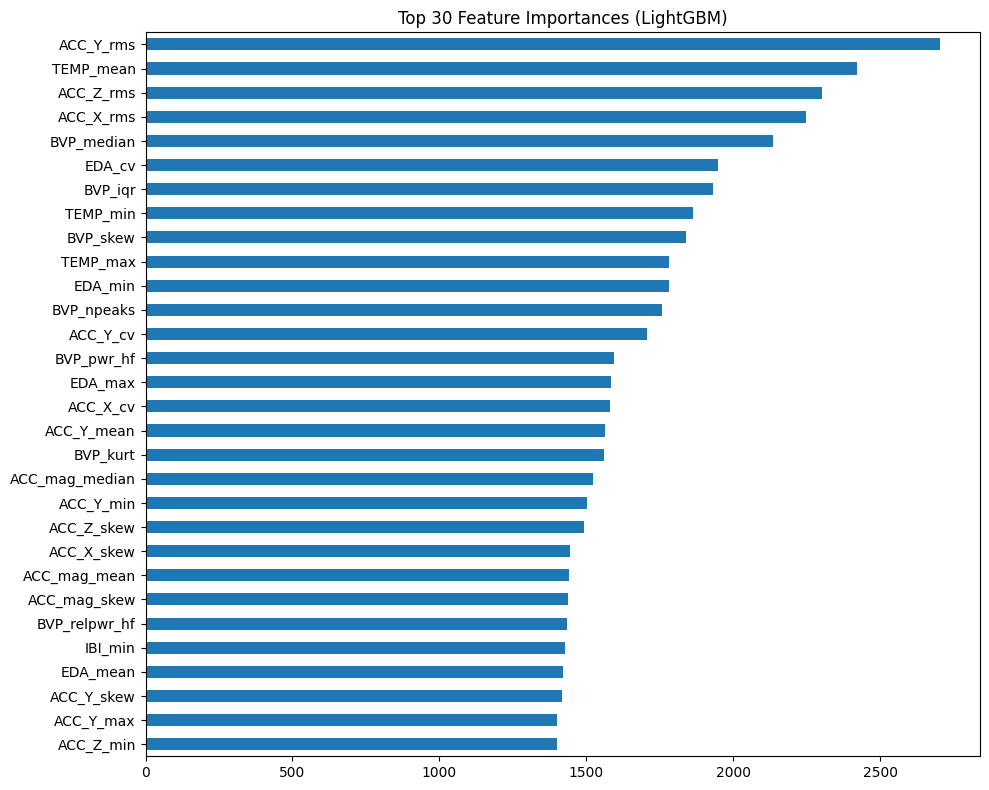

In [ ]:
import matplotlib.pyplot as plt

fi = pd.Series(model.feature_importances_, index=X_train.columns)
fi_top = fi.sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 8))
fi_top.plot(kind='barh')
plt.title('Top 30 Feature Importances (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()